<a href="https://colab.research.google.com/github/ruforavishnu/Project_Machine_Learning/blob/master/Project19_Unsupervised_Learning_Social_Network_Graph_Analysis_using_Community_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install networkx python-louvain matplotlib

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import girvan_newman
import community

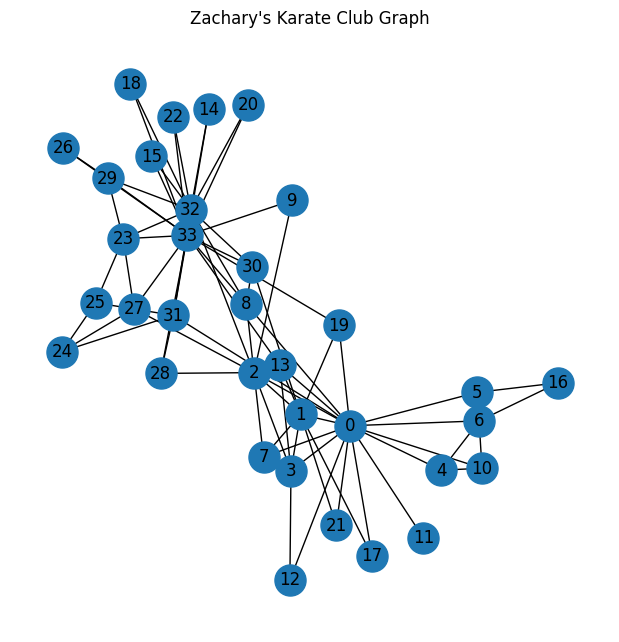

In [3]:
G = nx.karate_club_graph()

plt.figure(figsize=(6,6))
nx.draw(G,  with_labels=True,  node_size=500)
plt.title("Zachary's Karate Club Graph")
plt.show()

In [4]:
gn_comm = girvan_newman(G)
communities_gn = next(gn_comm)


print('Girvan-Newman Communities')

for i,c in enumerate(communities_gn):
  print(f'Community {i+1}:  {sorted(c)} ')



Girvan-Newman Communities
Community 1:  [0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21] 
Community 2:  [2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33] 


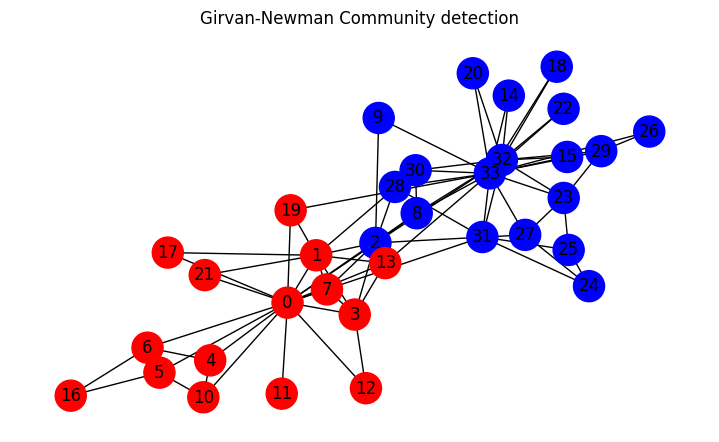

In [5]:
colors = ['red', 'blue', 'green', 'purple', 'orange']

color_map = {}



for i, community_nodes in enumerate(communities_gn):
  for node in community_nodes:
    color_map[node] = colors[i]


node_colors = [color_map[n] for n in G.nodes()]


plt.figure(figsize=(7,4))
nx.draw(G, with_labels=True,  node_color=node_colors,  node_size=500)
plt.title('Girvan-Newman Community detection')
plt.show()

### Nice !!

In [9]:
!pip install python-louvain


In [10]:
import community.community_louvain as community_louvain


In [12]:

partition = community_louvain.best_partition(G)


communities_louvain = {}

for node, comm_id in partition.items():
  communities_louvain.setdefault(comm_id,  []).append(node)



print('Louvain Communities')

for cid, members in communities_louvain.items():
  print(f'Community {cid}:  {sorted(members)}')





Louvain Communities
Community 0:  [0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21]
Community 2:  [4, 5, 6, 10, 16]
Community 3:  [8, 9, 14, 15, 18, 20, 22, 23, 26, 27, 29, 30, 32, 33]
Community 1:  [24, 25, 28, 31]


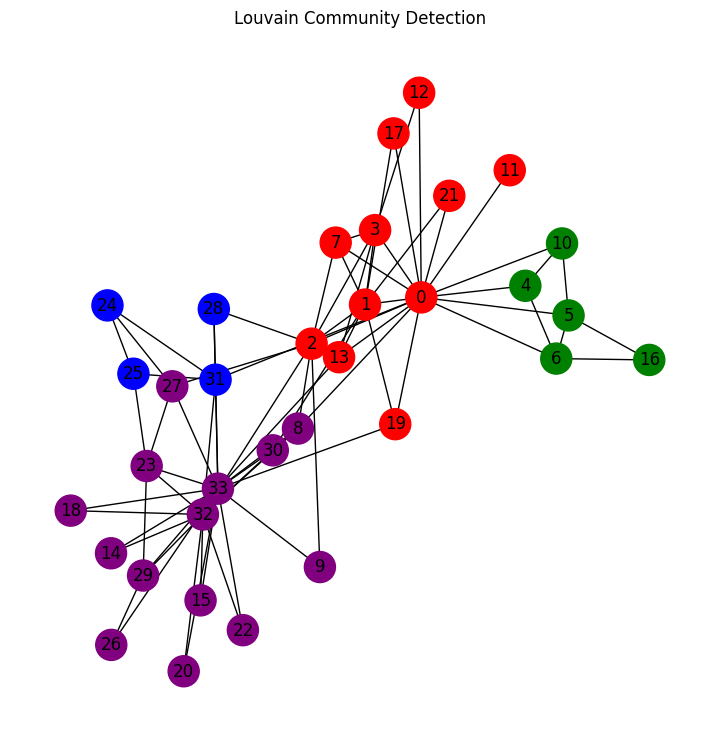

In [13]:
colors = ['red', 'blue', 'green', 'purple', 'orange']

node_colors = [colors[partition[n]] for n in G.nodes()]

plt.figure(figsize=(7,7))
nx.draw(G, with_labels=True,  node_color=node_colors,  node_size=500)
plt.title('Louvain Community Detection')
plt.show()



## Beautiful !

Lets just finish with print()ing the modularity score

In [15]:
modularity = community_louvain.modularity(partition, G)
print('Louvain Modularity score: ', modularity)



Louvain Modularity score:  0.44385412567230753


**Nice !**